# Topic modeling and macroeconomics
#### Replication of Bybee, Kelly, Manela, & Xiu (2021)

**Authors:** Emma LEGUAY, Carla LUCAS

**Institution:** ENSAE Paris / IP Paris

**Description:**
This notebook conducts the empirical analysis of the paper *BUSINESS NEWS AND BUSINESS CYCLES*. We evaluate the predictive power of news topics ($\theta$) extracted via LDA on various economic targets:
* **Section 1.1:** Macroeconomic time series 
* **Section 1.2:** Stock returns
* **Section 1.3:** Industry volatility
* **Section 1.4:** Economic Policy Uncertainty (EPU)

### *Import*

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import lars_path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas_datareader.data as web
import warnings
import os
from src.config import START_DATE, END_DATE, N_VARS_LASSO
from src.utils import *
from src.data_loader import *

warnings.filterwarnings('ignore')
print(f"Environment loaded. Analysis period: {START_DATE} to {END_DATE}")

Environment loaded. Analysis period: 1984-01-01 to 2017-06-01


In [2]:
theta, labels_map = load_topics('data')
print(f"Topics loaded: {theta.shape[1]} topics over {len(theta)} months.")

Topics loaded: 180 topics over 402 months.


### **Section 1. News attention and economic activity**

#### **1.1. Macroeconomic times series**

##### *1.1.1. Configuration and data*

In [3]:
NAME_MAPPING = {'IP': 'Industrial Production Growth','Emp': 'Employment Growth','MktRet': 'Market Returns','MktVol': 'Market Volatility'}

TICKERS = {'INDPRO': 'IP', 'PAYEMS': 'Emp', 'SPASTT01USM661N': 'MktRet', 'VIXCLS': 'MktVol'}

fred_raw = web.DataReader(list(TICKERS.keys()), 'fred', start='1980-01-01')
fred_m = fred_raw.resample('MS').mean()
data = pd.DataFrame(index=fred_m.index)
    
data['IP'] = np.log(fred_m['INDPRO']).diff() * 100
data['Emp'] = np.log(fred_m['PAYEMS']).diff() * 100
data['MktRet'] = np.log(fred_m['SPASTT01USM661N']).diff() * 100
data['MktVol'] = fred_m['VIXCLS'] 
data = data.dropna()

common = theta.index.intersection(data.index)
X = theta.loc[common]
Y = data.loc[common]

##### *1.1.2. Function*

In [4]:
def run_forecast_analysis(short_name, full_name, y_target, X_features):
    MIN_TRAIN_SIZE = 120
    N_VARS = 5
    
    # STANDARDIZATION 
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_std = pd.DataFrame(scaler_X.fit_transform(X_features), index=X_features.index, columns=X_features.columns)
    y_std = pd.Series(scaler_y.fit_transform(y_target.values.reshape(-1,1)).flatten(), index=y_target.index)
    
    # A. IN-SAMPLE ANALYSIS
    # Selection of top 5 variables
    top_5_vars = select_exact_k_lars(X_std, y_std, k=N_VARS)
    
    X_ols = sm.add_constant(X_std[top_5_vars])
    model = sm.OLS(y_std, X_ols).fit()
    r2_in = model.rsquared
    
    # B. OUT-OF-SAMPLE ANALYSIS
    trues_oos = []
    preds_oos = []
    hist_means = []
    
    for i in range(MIN_TRAIN_SIZE, len(y_std)):
        y_train = y_std.iloc[:i]
        X_train = X_std.iloc[:i]
        y_test_pt = y_std.iloc[i]
        X_test_row = X_std.iloc[[i]]
        
        # Selection of top 5 variables
        vars_t = select_exact_k_lars(X_train, y_train, k=N_VARS)
        
        # Fit & predict
        reg = LinearRegression().fit(X_train[vars_t], y_train)
        pred = reg.predict(X_test_row[vars_t])[0]
        
        preds_oos.append(pred)
        trues_oos.append(y_test_pt)
        hist_means.append(y_train.mean())

    # R2 OOS
    mse_model = np.mean((np.array(trues_oos) - np.array(preds_oos))**2)
    mse_bench = np.mean((np.array(trues_oos) - np.array(hist_means))**2)
    r2_out = 1 - (mse_model / mse_bench)
    
    # C. TABLES
    res = pd.DataFrame({
        'Coeff': model.params[top_5_vars], 
        'Pval': model.pvalues[top_5_vars]
    })
    res['Topic'] = [labels_map.get(str(v), v) if str(v) in labels_map else labels_map.get(v, v) for v in res.index]
    res = res.sort_values(by='Coeff', key=abs, ascending=False)
    
    print(f"\n{'-'*75}")
    print(f"TABLE : {full_name.upper()}")
    print(f"{'-'*75}")
    print(f"{'Topic':<35} | {'Coeff.':>7} | {'P-val':>8} | {'Sig'}")
    print(f"{'-'*75}")
    
    for _, row in res.iterrows():
        star = get_stars(row['Pval'])
        print(f"{row['Topic']:<35} | {row['Coeff']:>7.2f} | {row['Pval']:>8.4f} | {star}")
        
    print(f"{'-'*75}")
    print(f"In-Sample R2     : {r2_in:.2f}")
    print(f"Out-of-Sample R2 : {r2_out:.2f}")
    print(f"{'-'*75}")
    
    # D. GRAPHS
    vars_final = select_exact_k_lars(X_std, y_std, k=N_VARS)
    reg_final = LinearRegression().fit(X_std[vars_final], y_std)
    preds_in_sample = reg_final.predict(X_std[vars_final])

    dates_oos = y_std.index[MIN_TRAIN_SIZE:] 
    preds_oos_aligned = pd.Series(preds_oos, index=dates_oos)

    plt.figure(figsize=(12, 5))
    plt.plot(y_std.index, y_std, 'k-', lw=1, alpha=0.3, label='Actual Data')
    plt.plot(y_std.index, preds_in_sample, 'b--', lw=1, alpha=0.8, label='In-Sample Fit (Explain)')
    plt.plot(dates_oos, preds_oos_aligned, 'r-', lw=1.5, label='Out-of-Sample Forecast')
    
    plt.axvline(y_std.index[MIN_TRAIN_SIZE], color='gray', linestyle=':', label='OOS Start')
    plt.title(f"{full_name}: Topic Model Performance")
    plt.legend()
    plt.tight_layout()
    
    plt.show()

##### *1.1.3. Execution*


---------------------------------------------------------------------------
TABLE : INDUSTRIAL PRODUCTION GROWTH
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |   -0.31 |   0.0000 | ***
Oil market                          |   -0.19 |   0.0002 | ***
Southeast Asia                      |    0.14 |   0.0061 | ***
Committees                          |    0.13 |   0.0174 | **
Restraint                           |   -0.10 |   0.0456 | **
---------------------------------------------------------------------------
In-Sample R2     : 0.26
Out-of-Sample R2 : 0.06
---------------------------------------------------------------------------


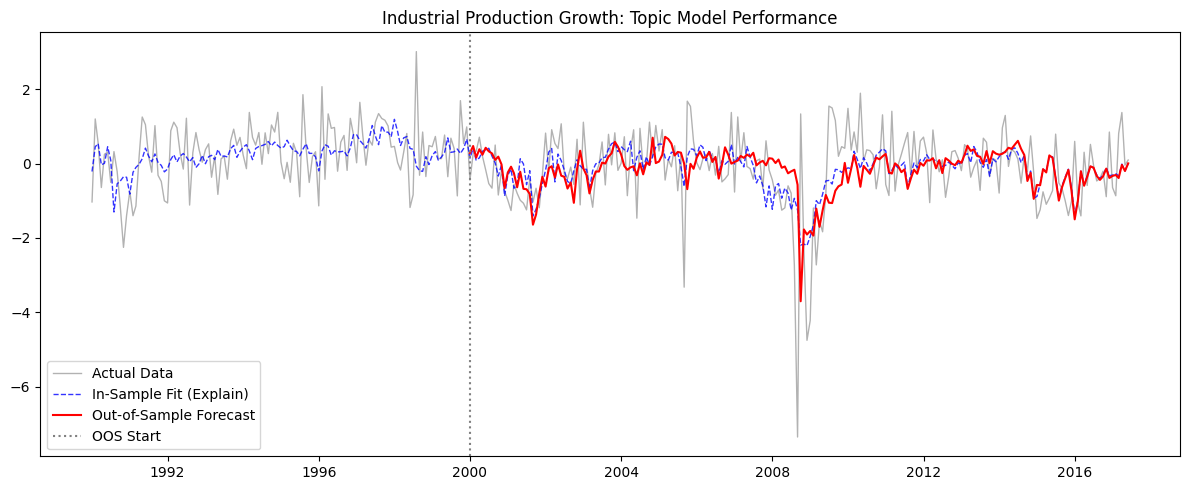


---------------------------------------------------------------------------
TABLE : EMPLOYMENT GROWTH
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |   -0.57 |   0.0000 | ***
Clintons                            |    0.26 |   0.0000 | ***
Short sales                         |   -0.17 |   0.0000 | ***
Bankruptcy                          |   -0.15 |   0.0004 | ***
Credit ratings                      |   -0.03 |   0.4263 | 
---------------------------------------------------------------------------
In-Sample R2     : 0.63
Out-of-Sample R2 : 0.56
---------------------------------------------------------------------------


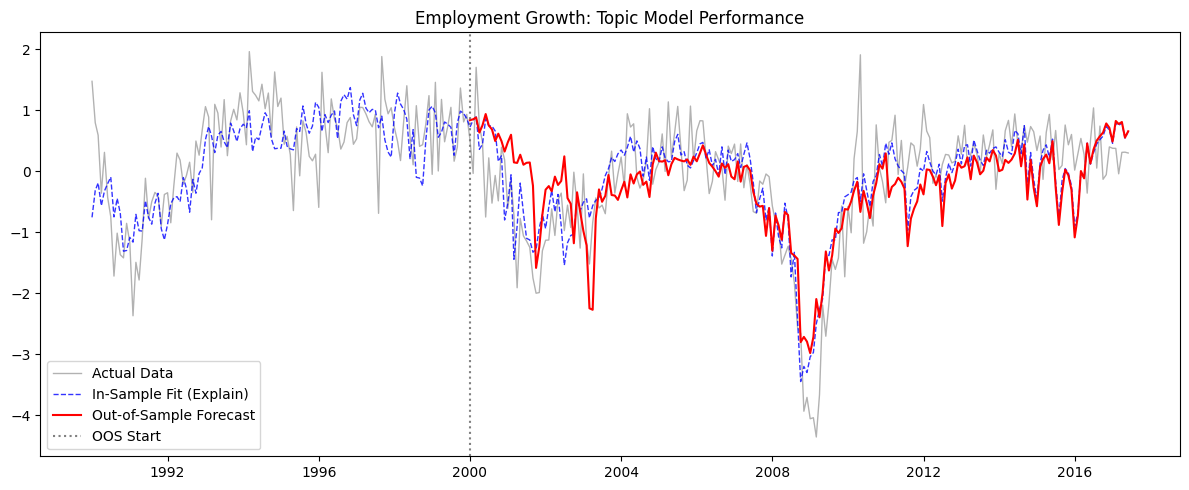


---------------------------------------------------------------------------
TABLE : MARKET RETURNS
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Problems                            |   -0.25 |   0.0002 | ***
Recession                           |   -0.18 |   0.0073 | ***
Oil market                          |   -0.16 |   0.0020 | ***
Bear/bull market                    |   -0.12 |   0.0198 | **
Health insurance                    |    0.07 |   0.1477 | 
---------------------------------------------------------------------------
In-Sample R2     : 0.24
Out-of-Sample R2 : 0.14
---------------------------------------------------------------------------


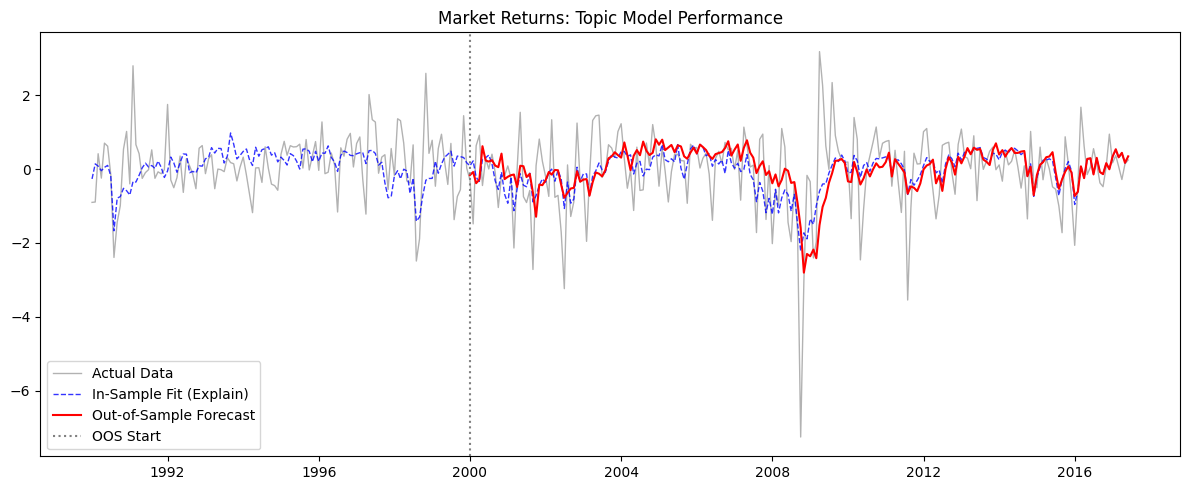


---------------------------------------------------------------------------
TABLE : MARKET VOLATILITY
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |    0.56 |   0.0000 | ***
Problems                            |    0.30 |   0.0000 | ***
Options/VIX                         |    0.14 |   0.0004 | ***
Small caps                          |    0.12 |   0.0138 | **
Bear/bull market                    |    0.10 |   0.0084 | ***
---------------------------------------------------------------------------
In-Sample R2     : 0.73
Out-of-Sample R2 : 0.67
---------------------------------------------------------------------------


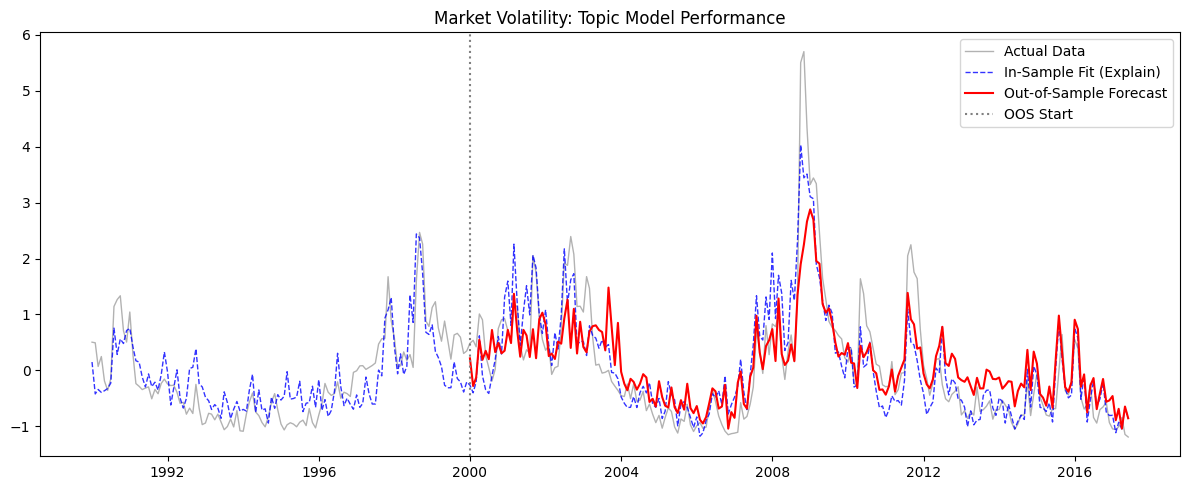

In [5]:
for short_col, full_name in NAME_MAPPING.items():
    if short_col in Y.columns:
        run_forecast_analysis(short_col, full_name, Y[short_col], X)

#### **1.2. Stock returns**

##### *1.2.1. Configuration and data*

In [6]:
TARGET_START = '1984-01-01'
TARGET_END = '2017-06-01'

CFNAI_IDS = {'CFNAI': 'CFNAI', 'PANDI': 'Prod_Inc', 'EUANDH': 'Emp_Hrs', 'CANDH': 'Cons_Hous', 'SOANDI': 'Sales_Ord'}
FRED_MD_IDS = ['INDPRO', 'PAYEMS', 'UNRATE', 'HOUST', 'PPIACO', 'PCEPI', 'M2SL', 'FEDFUNDS']

# 1. Download
# A. Target (S&P 500)
sp500 = web.DataReader('SPASTT01USM661N', 'fred', start='1950-01-01')
mkt_ret = np.log(sp500).diff() * 100
mkt_ret.columns = ['MktRet']
mkt_ret = mkt_ret.dropna()

# B. Benchmarks
cfnai_raw = web.DataReader(list(CFNAI_IDS.keys()), 'fred', start='1960').rename(columns=CFNAI_IDS).resample('MS').mean().dropna(axis=1, how='all')
cfnai_innov = get_ar1_innovations(cfnai_raw)

fred_list = [web.DataReader(c, 'fred', start='1960').resample('MS').mean() for c in FRED_MD_IDS]
fred_raw = pd.concat(fred_list, axis=1)
fred_stat = np.log(fred_raw).diff() * 100        
fred_innov = get_ar1_innovations(fred_stat)

# 2. Alignment
common = mkt_ret.index.intersection(theta.index)
common = common[(common >= TARGET_START) & (common <= TARGET_END)]
final_idx = common.intersection(cfnai_innov.index).intersection(fred_innov.index)

y = mkt_ret.loc[final_idx]
X_topics = theta.loc[final_idx]
X_cfnai = cfnai_innov.loc[final_idx]
X_fred = fred_innov.loc[final_idx]

##### *1.2.2. Function*

In [7]:
def run_standardized_analysis(y_target, X_news, X_bench, bench_name):
    if X_bench.empty: return

    # Standardization
    scaler = StandardScaler()
    y_std = pd.Series(scaler.fit_transform(y_target.values.reshape(-1, 1)).flatten(), index=y_target.index)
    X_news_std = pd.DataFrame(scaler.fit_transform(X_news), index=X_news.index, columns=X_news.columns)
    X_bench_std = pd.DataFrame(scaler.fit_transform(X_bench), index=X_bench.index, columns=X_bench.columns)


    # 1. Benchmark model
    if X_bench.shape[1] <= 5:
        model_b = sm.OLS(y_std, sm.add_constant(X_bench_std)).fit()
    else:
        # Selection of top 5 variables
        vars_b = select_exact_k_lars(X_bench_std, y_std, k=5)
        model_b = sm.OLS(y_std, sm.add_constant(X_bench_std[vars_b])).fit()
        
    bench_r2 = model_b.rsquared


    # 2. Full model (topic + macro)
    X_pool = pd.concat([X_news_std, X_bench_std], axis=1)
    
    # Selection of top 5 variables
    selected_vars = select_exact_k_lars(X_pool, y_std, k=5)
    
    # Final model
    full_model = sm.OLS(y_std, sm.add_constant(X_pool[selected_vars])).fit()
    
    print(f"\n{'-'*75}")
    print(f"TABLE 2: TOPIC MODEL & {bench_name}")
    print(f"{'-'*75}")
    print(f"{'Topic / Variable':<35} | {'Coeff.':>7} | {'P-val':>8} | {'Sig'}")
    print(f"{'-'*75}")
    
    res = pd.DataFrame({
        'Name': selected_vars,
        'Coeff': full_model.params[selected_vars],
        'Pval': full_model.pvalues[selected_vars]
    }).sort_values(by='Coeff', key=abs, ascending=False)
    
    for _, row in res.iterrows():
        var_name = str(row['Name'])
        
        if var_name in labels_map:
            display_name = labels_map[var_name]
        elif var_name in CFNAI_IDS.values():
            display_name = f"[CFNAI] {var_name}"
        else:
            display_name = f"[MACRO] {var_name}"
            
        star = get_stars(row['Pval'])
        print(f"{display_name:<35} | {row['Coeff']:>7.2f} | {row['Pval']:>8.4f} | {star}")
        
    print(f"{'-'*75}")
    print(f"Full R2      : {full_model.rsquared:.2f}")
    print(f"Benchmark R2 : {bench_r2:.2f}")
    print(f"{'-'*75}")

##### *1.2.3. Execution*

In [8]:
run_standardized_analysis(y, X_topics, X_cfnai, "CFNAI")
run_standardized_analysis(y, X_topics, X_fred, "FRED-MD")


---------------------------------------------------------------------------
TABLE 2: TOPIC MODEL & CFNAI
---------------------------------------------------------------------------
Topic / Variable                    |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Problems                            |   -0.22 |   0.0001 | ***
Recession                           |   -0.21 |   0.0002 | ***
Federal Reserve                     |   -0.17 |   0.0002 | ***
Bear/bull market                    |   -0.13 |   0.0044 | ***
Health insurance                    |    0.12 |   0.0115 | **
---------------------------------------------------------------------------
Full R2      : 0.23
Benchmark R2 : 0.05
---------------------------------------------------------------------------

---------------------------------------------------------------------------
TABLE 2: TOPIC MODEL & FRED-MD
-----------------------------------------------------------------

#### **1.3. Industry volatily**

##### *1.3.1. Configuration and data*

In [9]:
kf_daily = get_ken_french_49_daily()

##### *1.3.2. Function*

In [ ]:
def run_industry_volatility_analysis(theta, kf_daily, labels_map, start_date='1984-01-01', end_date='2017-06-01'):    

    # 1. INDUSTRY VOLATILITY PREPARATION
    # Monthly volatility 
    vol_monthly = kf_daily.resample('MS').std()

    mask = (vol_monthly.index >= start_date) & (vol_monthly.index <= end_date)
    vol_monthly = vol_monthly.loc[mask]
    
    # Log transform 
    vol_log = np.log(vol_monthly + 1e-6)
    
    # PCA on standardized log-vol 
    pca = PCA(n_components=1)
    vol_log_std = StandardScaler().fit_transform(vol_log)
    common_factor = pca.fit_transform(vol_log_std)
    
    # Orthogonalization 
    vol_ortho = pd.DataFrame(index=vol_log.index, columns=vol_log.columns)
    X_factor = sm.add_constant(common_factor)
    
    for col in vol_log.columns:
        vol_ortho[col] = sm.OLS(vol_log[col], X_factor).fit().resid
        
    # 2. INNOVATIONS AR(1) & ALIGNMENT
    # Innovations (AR1 residuals) 
    industry_innov = get_ar1_innovations(vol_ortho)
    theta_innov = get_ar1_innovations(theta)
    
    common_idx = industry_innov.index.intersection(theta_innov.index)
    industry_innov = industry_innov.loc[common_idx]
    theta_innov = theta_innov.loc[common_idx]
        
    # 3. SECTOR-WISE ANALYSIS (LOOP)
    TARGET_SECTORS = {
        'Automotive': ['Autos', 'Auto'], 
        'Banking': ['Banks', 'Bank'], 
        'Computers': ['Hrdwr', 'Hardw', 'Comps'], 
        'Oil': ['Oil', 'Oil  '],
        'Tobacco': ['Smoke'],
        'Pharmaceuticals': ['Drugs', 'Drug', 'Pharma']
    }
    
    for name, keywords in TARGET_SECTORS.items():
        col_name = None
        for col in industry_innov.columns:
            clean_col = col.strip().lower()
            if any(k.lower() == clean_col for k in keywords):
                col_name = col
                break
        
        if col_name:
            y_target = industry_innov[col_name]
            
            # Standardization 
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            
            X_s = pd.DataFrame(scaler_X.fit_transform(theta_innov), index=theta_innov.index, columns=theta_innov.columns)
            y_s = pd.Series(scaler_y.fit_transform(y_target.values.reshape(-1,1)).flatten(), index=y_target.index)
            
            # Selection of top 5 variables
            top_vars = select_exact_k_lars(X_s, y_s, k=5)
            
            # OLS 
            model = sm.OLS(y_s, sm.add_constant(X_s[top_vars])).fit()
            
            print(f"{'-'*65}")
            print(f"TABLE : {name.upper()} ({col_name}) | R2 = {model.rsquared:.2f}")
            print(f"{'-'*65}")
            
            res = pd.DataFrame({
                'Coeff': model.params[top_vars],
                'Pval': model.pvalues[top_vars]
            })
            
            res['Topic'] = [labels_map.get(str(v), v) if str(v) in labels_map else labels_map.get(v, v) for v in res.index]
            res = res.reindex(res['Coeff'].abs().sort_values(ascending=False).index)
            
            for _, row in res.iterrows():
                star = get_stars(row['Pval']) 
                print(f"{row['Topic']:<35} | {row['Coeff']:>6.2f} {star}")
            
            print(f"{'-'*65}\n")
        else:
            print(f"There is no sector : {name} (Keywords : {keywords})")

##### *1.3.3. Execution*

In [11]:
run_industry_volatility_analysis(theta, kf_daily, labels_map, START_DATE, END_DATE)

-----------------------------------------------------------------
TABLE 4: AUTOMOTIVE (Autos) | R2 = 0.11
-----------------------------------------------------------------
M&A                                 |  -0.17 ***
Soft drinks                         |  -0.16 ***
Product prices                      |   0.14 ***
Sales call                          |  -0.12 **
NASD                                |  -0.07 
-----------------------------------------------------------------

-----------------------------------------------------------------
TABLE 4: BANKING (Banks) | R2 = 0.11
-----------------------------------------------------------------
Mortgages                           |   0.20 ***
Software                            |   0.18 ***
Options/VIX                         |  -0.17 ***
Gender issues                       |   0.12 **
Schools                             |   0.09 *
-----------------------------------------------------------------

------------------------------------------

#### **1.4. Economic policy uncertainty**

##### *1.4.1. Configuration and data*

In [12]:
END_DATE_PAPER = '2017-06-01'

TARGET_MAP = {
    'Broad EPU': ['Economic Policy Uncertainty', 'News_Based_Policy_Uncert_Index'],
    'Entitlement Programs': ['Entitlement Programs', 'Entitlement'],
    'Financial Regulation': ['Financial Regulation', 'Financial'],
    'Fiscal Policy': ['Fiscal Policy', 'Fiscal'],
    'Government Spending': ['Government Spending'],
    'Health Care': ['Health Care', 'Healthcare'],
    'Monetary Policy': ['Monetary Policy'],
    'National Security': ['National Security'],
    'Regulation': ['Regulation'],
    'Sovereign Debt': ['Sovereign Debt'],
    'Taxes': ['Taxes', 'Tax'],
    'Trade Policy': ['Trade Policy']
}


# EPU Excel
file_path = 'data/Categorical_EPU_Data.xlsx'
epu_raw = pd.read_excel(file_path)
        
# Date cleaning
epu_raw = epu_raw.dropna(subset=['Year', 'Month'])
epu_raw['Date'] = pd.to_datetime(epu_raw['Year'].astype(int).astype(str) + '-' + epu_raw['Month'].astype(int).astype(str) + '-01')
epu_raw = epu_raw.set_index('Date').sort_index()
        
cols_to_keep = [c for c in epu_raw.columns if c not in ['Year', 'Month']]
epu_cats = epu_raw[cols_to_keep]
        
# Log transform
epu_cats_log = np.log(epu_cats + 1)
        
# Alignment
common = theta.index.intersection(epu_cats_log.index)
common = common[common <= END_DATE_PAPER]

X_topics = theta.loc[common]
Y_epu = epu_cats_log.loc[common]

##### *1.4.2. Function*

In [13]:
def analyze_epu_category(cat_display_name, y_series, X_topics, labels_map):
    # Standardization
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_s = pd.DataFrame(scaler_X.fit_transform(X_topics), index=X_topics.index, columns=X_topics.columns)
    y_s = pd.Series(scaler_y.fit_transform(y_series.values.reshape(-1, 1)).flatten(), index=y_series.index)
    
    # Selection of top 5 variables
    top_indices = select_exact_k_lars(X_s, y_s, k=5)
    
    # Indices vs names handling
    if len(top_indices) > 0 and isinstance(top_indices[0], (int, np.integer)):
        selected_vars = X_s.columns[top_indices]
    else:
        selected_vars = top_indices 
    if len(selected_vars) == 0: return 
    
    # OLS
    model = sm.OLS(y_s, sm.add_constant(X_s[selected_vars])).fit()
    
    print(f"\n{'-'*75}") 
    print(f"--- {cat_display_name.upper()} (R2 = {model.rsquared:.2f}) ---")
    print(f"{'-'*75}")
    print(f"{'Topic':<35} | {'Coeff':>6} | {'P-val':>8} | {'Sig'}")
    print(f"{'-'*75}")
    
    res = pd.DataFrame({
        'Coeff': model.params[selected_vars],
        'Pval': model.pvalues[selected_vars]
    })
    
    res['Topic'] = [labels_map.get(str(v), v) if str(v) in labels_map else labels_map.get(v, v) for v in res.index]
    res = res.reindex(res['Coeff'].abs().sort_values(ascending=False).index)
    
    for _, row in res.iterrows():
        star = get_stars(row['Pval'])
        print(f"{row['Topic']:<35} | {row['Coeff']:>6.2f} | {row['Pval']:>8.4f} | {star}")

##### *1.4.3. Execution*

In [14]:
for display_name, search_keys in TARGET_MAP.items():
    found_col = None
    for col in Y_epu.columns:
        for key in search_keys:
            if key.lower().strip() in col.lower().strip():
                found_col = col
                break
        if found_col: break
        
    if found_col:
        analyze_epu_category(display_name, Y_epu[found_col], X_topics, labels_map)
    else:
        print(f"Data for '{display_name}' not found.")


---------------------------------------------------------------------------
--- BROAD EPU (R2 = 0.57) ---
---------------------------------------------------------------------------
Topic                               |  Coeff |    P-val | Sig
---------------------------------------------------------------------------
M&A                                 |  -0.36 |   0.0000 | ***
Problems                            |   0.29 |   0.0000 | ***
Government budgets                  |   0.28 |   0.0000 | ***
Restraint                           |   0.16 |   0.0000 | ***
Bank loans                          |   0.09 |   0.0392 | **

---------------------------------------------------------------------------
--- ENTITLEMENT PROGRAMS (R2 = 0.43) ---
---------------------------------------------------------------------------
Topic                               |  Coeff |    P-val | Sig
---------------------------------------------------------------------------
Government budgets                  | 

### **Section 2. Emma**